In [12]:
# CELL 1 — vit_small_patch16_224  (22M params, 384 feat_dim, supervised IN1K pretraining)
# Same architecture and tuning as the DINO ViT cell above; only the pretrained weights differ.
# This row in the benchmark answers: "DINO vs supervised pretraining for the same ViT?"

import os, time, copy, random
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms
import timm

import torchquantum as tq
import torchquantum.functional as tqf

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_fscore_support,
)
from sklearn.preprocessing import label_binarize


SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

TRAIN_DIR = "/home/jovyan/ssh-test-datavol-1/dataset/dataset/train"
VAL_DIR   = "/home/jovyan/ssh-test-datavol-1/dataset/dataset/val"

CKPT_ROOT    = "./checkpoints"
STAGE1_DIR   = os.path.join(CKPT_ROOT, "stage1")
STAGE2_DIR   = os.path.join(CKPT_ROOT, "stage2")
BASELINE_DIR = os.path.join(CKPT_ROOT, "baseline")
for d in (CKPT_ROOT, STAGE1_DIR, STAGE2_DIR, BASELINE_DIR):
    os.makedirs(d, exist_ok=True)


def _safe_name(s: str) -> str:
    return s.replace("/", "__").replace(".", "_").replace(":", "_")


CFG: Dict[str, Any] = {
    "backbone":    "vit_small_patch16_224",
    "pretrained":  True,

    "n_qubits":    8,
    "n_qlayers":   1,
    "n_classes":   3,
    "class_names": ["no", "sphere", "vort"],

    "input_size":   150,
    "resize_to":    224,
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std":  [0.229, 0.224, 0.225],

    "batch_size":  256,
    "test_split":  0.10,

    "class_weights":    [1.0, 2.5, 2.0],
    "grad_clip":        1.0,
    "warmup_epochs":    5,
    "use_augmentation": True,

    # ===== Stage 1 =====
    "stage1_epochs":      50,
    "stage1_wd":          5e-4,
    "stage1_lr_backbone": 5e-5,
    "stage1_lr_bridge":   5e-4,
    "stage1_lr_quantum":  5e-3,

    # ===== Stage 2 =====
    "stage2_epochs": 60,
    "stage2_wd":     1e-4,
    "lr_backbone":   3e-5,
    "lr_bridge":     2e-4,
    "lr_quantum":    5e-3,

    "seed": SEED,
}

_bb = _safe_name(CFG["backbone"])
CFG["stage1_ckpt"]   = os.path.join(STAGE1_DIR,   f"{_bb}.pth")
CFG["stage2_ckpt"]   = os.path.join(STAGE2_DIR,   f"{_bb}.pth")
CFG["baseline_ckpt"] = os.path.join(BASELINE_DIR, f"{_bb}.pth")

print(f"PyTorch {torch.__version__} | TorchQuantum {tq.__version__} | timm {timm.__version__}")
print(f"Device: {device} | CUDA: {torch.cuda.is_available()}")
print(f"Backbone: {CFG['backbone']}  pretrained={CFG['pretrained']}")
print(f"Stage 1 LRs: backbone={CFG['stage1_lr_backbone']} bridge={CFG['stage1_lr_bridge']} quantum={CFG['stage1_lr_quantum']}")
print(f"Stage 2 LRs: backbone={CFG['lr_backbone']} bridge={CFG['lr_bridge']} quantum={CFG['lr_quantum']}")
print(f"class_weights={CFG['class_weights']}, grad_clip={CFG['grad_clip']}, "
      f"warmup={CFG['warmup_epochs']}, use_augmentation={CFG['use_augmentation']}")
print(f"\nCheckpoint layout:")
print(f"  stage1   -> {CFG['stage1_ckpt']}")
print(f"  stage2   -> {CFG['stage2_ckpt']}")
print(f"  baseline -> {CFG['baseline_ckpt']}")

PyTorch 2.5.1+cu124 | TorchQuantum 0.1.8 | timm 1.0.26
Device: cuda:0 | CUDA: True
Backbone: vit_small_patch16_224  pretrained=True
Stage 1 LRs: backbone=5e-05 bridge=0.0005 quantum=0.005
Stage 2 LRs: backbone=3e-05 bridge=0.0002 quantum=0.005
class_weights=[1.0, 2.5, 2.0], grad_clip=1.0, warmup=5, use_augmentation=True

Checkpoint layout:
  stage1   -> ./checkpoints/stage1/vit_small_patch16_224.pth
  stage2   -> ./checkpoints/stage2/vit_small_patch16_224.pth
  baseline -> ./checkpoints/baseline/vit_small_patch16_224.pth


In [7]:
# CELL 2 — preprocess once on GPU, serve at memcpy speed; label-preserving augmentation

class GPUTensorDataset:
    def __init__(self, cache: torch.Tensor, labels: torch.Tensor, classes: List[str]):
        self.cache  = cache
        self.labels = labels
        self.classes = classes
    def __len__(self) -> int:
        return self.cache.size(0)


class GPULoader:
    def __init__(self, dataset: GPUTensorDataset, batch_size: int,
                 shuffle: bool = False, seed: int = 42):
        self.dataset = dataset
        self.bs = batch_size
        self.shuffle = shuffle
        self.seed = seed
        self._epoch = 0

    def __len__(self) -> int:
        return (len(self.dataset) + self.bs - 1) // self.bs

    def __iter__(self):
        n   = len(self.dataset)
        dev = self.dataset.cache.device
        if self.shuffle:
            g = torch.Generator(); g.manual_seed(self.seed + self._epoch)
            perm = torch.randperm(n, generator=g).to(dev)
        else:
            perm = torch.arange(n, device=dev)
        self._epoch += 1
        cache, labels = self.dataset.cache, self.dataset.labels
        for i in range(0, n, self.bs):
            idx = perm[i:i + self.bs]
            yield cache.index_select(0, idx).float(), labels.index_select(0, idx)


def build_gpu_cache(root_dir, resize_to, mean, std, device,
                    dtype: torch.dtype = torch.float32, chunk: int = 256):
    classes = sorted([d for d in os.listdir(root_dir)
                      if os.path.isdir(os.path.join(root_dir, d))])
    class_to_idx = {c: i for i, c in enumerate(classes)}
    files: List[Tuple[str, int]] = []
    for c in classes:
        cdir = os.path.join(root_dir, c)
        for f in os.listdir(cdir):
            if f.endswith(".npy"):
                files.append((os.path.join(cdir, f), class_to_idx[c]))

    N = len(files)
    cache  = torch.empty((N, 3, resize_to, resize_to), dtype=dtype,        device=device)
    labels = torch.empty((N,),                          dtype=torch.long, device=device)
    m = torch.tensor(mean, device=device, dtype=torch.float32).view(1, 3, 1, 1)
    s = torch.tensor(std,  device=device, dtype=torch.float32).view(1, 3, 1, 1)

    print(f"Caching {N} samples from {root_dir} -> GPU 3x{resize_to}x{resize_to} {dtype}")
    for cs in tqdm(range(0, N, chunk), desc="cache build"):
        ce = min(cs + chunk, N)
        cpu_imgs, cpu_lbls = [], []
        for fp, lbl in files[cs:ce]:
            arr = np.load(fp)
            if arr.ndim == 2:
                arr = arr[np.newaxis, :, :]
            elif arr.ndim == 3 and arr.shape[0] not in (1, 3):
                arr = arr.transpose(2, 0, 1)
            if arr.max() > 1.0:
                arr = arr / 255.0
            t = torch.from_numpy(np.ascontiguousarray(arr)).float()
            if t.shape[0] == 1:
                t = t.repeat(3, 1, 1)
            cpu_imgs.append(t)
            cpu_lbls.append(lbl)
        batch = torch.stack(cpu_imgs, dim=0).to(device, non_blocking=True)
        batch = F.interpolate(batch, size=(resize_to, resize_to),
                              mode="bilinear", align_corners=False)
        batch = (batch - m) / s
        cache[cs:ce]  = batch.to(dtype)
        labels[cs:ce] = torch.tensor(cpu_lbls, dtype=torch.long, device=device)
    return GPUTensorDataset(cache, labels, classes)


class GPUAugment(nn.Module):
    """Per-sample h/v flips + per-batch 90-deg rotation. All label-preserving."""
    def __init__(self, p_hflip: float = 0.5, p_vflip: float = 0.5, p_rot90: float = 0.75):
        super().__init__()
        self.p_hflip = p_hflip
        self.p_vflip = p_vflip
        self.p_rot90 = p_rot90

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.shape[0]; dev = x.device
        m = (torch.rand(B, device=dev) < self.p_hflip).view(B, 1, 1, 1)
        x = torch.where(m, x.flip(-1), x)
        m = (torch.rand(B, device=dev) < self.p_vflip).view(B, 1, 1, 1)
        x = torch.where(m, x.flip(-2), x)
        if torch.rand(1, device=dev).item() < self.p_rot90:
            k = int(torch.randint(1, 4, (1,)).item())
            x = torch.rot90(x, k, dims=[-2, -1])
        return x


# === build caches and loaders ===
CACHE_DTYPE = torch.float32
t0 = time.time()
train_set = build_gpu_cache(TRAIN_DIR, CFG["resize_to"], CFG["imagenet_mean"], CFG["imagenet_std"],
                            device, dtype=CACHE_DTYPE)
val_full  = build_gpu_cache(VAL_DIR, CFG["resize_to"], CFG["imagenet_mean"], CFG["imagenet_std"],
                            device, dtype=CACHE_DTYPE)
print(f"Cache build took {time.time()-t0:.1f}s | "
      f"GPU mem allocated {torch.cuda.memory_allocated()/1e9:.2f} GB")

g = torch.Generator().manual_seed(CFG["seed"])
n_total = len(val_full); n_test = int(n_total * CFG["test_split"])
perm = torch.randperm(n_total, generator=g)
val_idx, test_idx = perm[n_test:].to(device), perm[:n_test].to(device)
val_set  = GPUTensorDataset(val_full.cache.index_select(0, val_idx),
                            val_full.labels.index_select(0, val_idx), val_full.classes)
test_set = GPUTensorDataset(val_full.cache.index_select(0, test_idx),
                            val_full.labels.index_select(0, test_idx), val_full.classes)
del val_full; torch.cuda.empty_cache()

train_loader = GPULoader(train_set, batch_size=CFG["batch_size"], shuffle=True,  seed=CFG["seed"])
val_loader   = GPULoader(val_set,   batch_size=CFG["batch_size"], shuffle=False)
test_loader  = GPULoader(test_set,  batch_size=CFG["batch_size"], shuffle=False)

augmenter = GPUAugment().to(device) if CFG["use_augmentation"] else None
print(f"Augmentation: {'ON' if augmenter is not None else 'OFF'}")

CLASS_NAMES = train_set.classes
assert CLASS_NAMES == CFG["class_names"], f"class mismatch: {CLASS_NAMES}"
print(f"Sizes: train={len(train_set)} val={len(val_set)} test={len(test_set)}")

import collections
counts = collections.Counter(train_set.labels.cpu().tolist())
print("Class counts (train):", {CLASS_NAMES[k]: v for k, v in sorted(counts.items())})

Caching 30000 samples from /home/jovyan/ssh-test-datavol-1/dataset/dataset/train -> GPU 3x224x224 torch.float32


cache build:   0%|          | 0/118 [00:00<?, ?it/s]

Caching 7500 samples from /home/jovyan/ssh-test-datavol-1/dataset/dataset/val -> GPU 3x224x224 torch.float32


cache build:   0%|          | 0/30 [00:00<?, ?it/s]

Cache build took 267.7s | GPU mem allocated 22.61 GB
Augmentation: ON
Sizes: train=30000 val=6750 test=750
Class counts (train): {'no': 10000, 'sphere': 10000, 'vort': 10000}


In [13]:
# CELL 3 — VQC ansatz: RY encode + (RX,RY,RZ + CNOT ring) x n_qlayers + PauliZ measure

class VQC(tq.QuantumModule):
    def __init__(self, n_wires: int = 8, n_qlayers: int = 1):
        super().__init__()
        self.n_wires = n_wires
        self.n_qlayers = n_qlayers
        self.encoder = tq.GeneralEncoder([
            {"input_idx": [i], "func": "ry", "wires": [i]} for i in range(n_wires)
        ])
        self.params_rx_dct = tq.QuantumModuleDict()
        self.params_ry_dct = tq.QuantumModuleDict()
        self.params_rz_dct = tq.QuantumModuleDict()
        for k in range(n_qlayers):
            for i in range(n_wires):
                key = str(i + k * n_wires)
                self.params_rx_dct[key] = tq.RX(has_params=True, trainable=True)
                self.params_ry_dct[key] = tq.RY(has_params=True, trainable=True)
                self.params_rz_dct[key] = tq.RZ(has_params=True, trainable=True)
        self.measure = tq.MeasureAll(tq.PauliZ)

    @tq.static_support
    def forward(self, x: torch.Tensor, q_device: tq.QuantumDevice):
        self.q_device = q_device
        self.encoder(self.q_device, x)
        for k in range(self.n_qlayers):
            for i in range(self.n_wires):
                key = str(i + k * self.n_wires)
                self.params_rx_dct[key](self.q_device, wires=i)
                self.params_ry_dct[key](self.q_device, wires=i)
                self.params_rz_dct[key](self.q_device, wires=i)
            for i in range(self.n_wires):
                tgt = 0 if i == self.n_wires - 1 else i + 1
                tqf.cnot(self.q_device, wires=[i, tgt],
                         static=self.static_mode, parent_graph=self.graph)
        return self.measure(self.q_device)

In [14]:
# CELL 4 — pluggable backbone via timm + per-backbone bridge norm
# (BN for classic CNNs, LN for ConvNeXt/ViT/Swin/DeiT/etc.)

def _is_modern_arch(name: str) -> bool:
    """
    Backbones that internally use LayerNorm/GELU. For these we use LayerNorm in the
    bridge MLP — avoids BN running-stats drift when the trunk produces high-variance
    features under heavy augmentation.
    """
    return any(name.lower().startswith(p) for p in (
        "convnext", "vit", "deit", "swin", "beit", "eva", "mobilevit", "coatnet",
    ))


def _make_bridge(in_dim: int, n_qubits: int, dropout: float = 0.2,
                 norm: str = "bn") -> nn.Sequential:
    """
    Bridge MLP:  in_dim -> 256 -> 128 -> 64 -> 32 -> n_qubits
    Norm + ReLU + Dropout(decreasing) BETWEEN layers; no activation on the final layer.
    `norm`: 'bn' (BatchNorm1d) for ResNet-style backbones,
            'ln' (LayerNorm)   for ConvNeXt / ViT / Swin / DeiT etc.
    """
    dims = [in_dim, 256, 128, 64, 32, n_qubits]
    layers: List[nn.Module] = []
    for i in range(len(dims) - 2):
        d = dropout * (1.0 - 0.2 * i)
        norm_layer = (nn.LayerNorm(dims[i + 1])
                      if norm.lower() == "ln"
                      else nn.BatchNorm1d(dims[i + 1]))
        layers += [
            nn.Linear(dims[i], dims[i + 1]),
            norm_layer,
            nn.ReLU(inplace=True),
            nn.Dropout(d),
        ]
    layers.append(nn.Linear(dims[-2], dims[-1]))
    seq = nn.Sequential(*layers)

    for m in seq.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return seq


class TimmFrontEnd(nn.Module):
    """timm trunk -> bridge MLP -> n_qubits, with the right norm chosen automatically."""
    def __init__(self, name: str, n_qubits: int, pretrained: bool = True):
        super().__init__()
        self.backbone = timm.create_model(name, pretrained=pretrained, num_classes=0)
        self.feat_dim = self.backbone.num_features
        self.n_qubits = n_qubits
        norm = "ln" if _is_modern_arch(name) else "bn"
        self.bridge_norm = norm
        self.bridge = _make_bridge(in_dim=self.feat_dim, n_qubits=n_qubits,
                                   dropout=0.2, norm=norm)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.bridge(self.backbone(x))


def get_frontend(name: str, n_qubits: int, pretrained: bool = True) -> nn.Module:
    return TimmFrontEnd(name, n_qubits=n_qubits, pretrained=pretrained)


# Smoke test + show which norm got picked
_fe = get_frontend(CFG["backbone"], n_qubits=CFG["n_qubits"], pretrained=CFG["pretrained"]).to(device)
_xb = torch.randn(2, 3, CFG["resize_to"], CFG["resize_to"], device=device)
_yb = _fe(_xb)
data_cfg = timm.data.resolve_model_data_config(_fe.backbone)
print(f"backbone        : {CFG['backbone']}")
print(f"bridge norm     : {_fe.bridge_norm.upper()}  "
      f"({'LayerNorm — ConvNeXt / ViT family' if _fe.bridge_norm == 'ln' else 'BatchNorm1d — classic CNN'})")
print(f"feat_dim        : {_fe.feat_dim} -> n_qubits={_fe.n_qubits}")
print(f"output shape    : {tuple(_yb.shape)} (expected (2, {CFG['n_qubits']}))")
print(f"timm cfg        : input={data_cfg.get('input_size')}, "
      f"mean={data_cfg.get('mean')}, std={data_cfg.get('std')}")
print(f"trainable params: {sum(p.numel() for p in _fe.parameters() if p.requires_grad):,}")
del _fe, _xb, _yb

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

backbone        : vit_small_patch16_224
bridge norm     : LN  (LayerNorm — ConvNeXt / ViT family)
feat_dim        : 384 -> n_qubits=8
output shape    : (2, 8) (expected (2, 8))
timm cfg        : input=(3, 224, 224), mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)
trainable params: 21,808,680


In [15]:
# CELL 5 — Stage 1 model: same architecture as Stage 2 (vqc_classifier.py:TTN_VQC analog)

class Stage1Model(nn.Module):
    """frontend -> sigmoid*pi/2 -> VQC -> Linear(n_qubits, n_classes) -> log_softmax"""
    def __init__(self, frontend: nn.Module, n_qubits: int, n_qlayers: int, n_classes: int):
        super().__init__()
        self.frontend = frontend
        self.n_qubits = n_qubits
        self.vqc  = VQC(n_wires=n_qubits, n_qlayers=n_qlayers)
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        bsz = x.shape[0]
        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=x.device)
        pre_out = self.frontend(x)
        q_in = torch.sigmoid(pre_out) * (np.pi / 2.0)
        q_out = self.vqc(q_in, qdev)
        return F.log_softmax(self.head(q_out), dim=1)


def build_stage1_model(cfg: Dict[str, Any]) -> Stage1Model:
    fe = get_frontend(cfg["backbone"], cfg["n_qubits"], pretrained=cfg["pretrained"])
    return Stage1Model(fe, n_qubits=cfg["n_qubits"],
                       n_qlayers=cfg["n_qlayers"], n_classes=cfg["n_classes"])


_m = build_stage1_model(CFG).to(device)
_xb = torch.randn(2, 3, CFG["resize_to"], CFG["resize_to"], device=device)
_yb = _m(_xb)
print(f"Stage1Model out shape: {tuple(_yb.shape)} (expected (2, {CFG['n_classes']}))")
print(f"Stage1Model params: {sum(p.numel() for p in _m.parameters()):,}")
print(f"  backbone : {sum(p.numel() for p in _m.frontend.backbone.parameters()):,}")
print(f"  bridge   : {sum(p.numel() for p in _m.frontend.bridge.parameters()):,}")
print(f"  vqc      : {sum(p.numel() for p in _m.vqc.parameters()):,}")
print(f"  head     : {sum(p.numel() for p in _m.head.parameters()):,}")
del _m, _xb, _yb

Stage1Model out shape: (2, 3) (expected (2, 3))
Stage1Model params: 21,808,731
  backbone : 21,665,664
  bridge   : 143,016
  vqc      : 24
  head     : 27


In [16]:
# CELL 6 — Stage 1 training (paper-faithful, with augmentation, weighted NLL, grad clip)

def get_stage1_param_groups(model: Stage1Model, cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    return [
        {"params": list(model.frontend.backbone.parameters()),
         "lr": cfg["stage1_lr_backbone"], "name": "backbone"},
        {"params": list(model.frontend.bridge.parameters()),
         "lr": cfg["stage1_lr_bridge"],   "name": "bridge"},
        {"params": list(model.vqc.parameters()) + list(model.head.parameters()),
         "lr": cfg["stage1_lr_quantum"],  "name": "quantum"},
    ]


def warmup_cosine_factor(epoch: int, warmup: int, total: int) -> float:
    if warmup > 0 and epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, total - warmup)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


def run_stage1(cfg, train_loader, val_loader, augmenter: Optional[nn.Module] = None):
    torch.manual_seed(cfg["seed"])
    model = build_stage1_model(cfg).to(device)

    cw = cfg.get("class_weights")
    if cw is not None and any(w != 1.0 for w in cw):
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.NLLLoss(weight=cw_t)
        print(f"[S1] using class weights {cw}")
    else:
        criterion = nn.NLLLoss()

    optimizer = optim.Adam(get_stage1_param_groups(model, cfg), weight_decay=cfg["stage1_wd"])
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda e: warmup_cosine_factor(e, cfg["warmup_epochs"], cfg["stage1_epochs"]),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None
    print(f"[S1] paper-faithful: frontend + VQC + Linear({cfg['n_qubits']}->{cfg['n_classes']})")
    print(f"[S1] augmentation: {'ON' if augmenter is not None else 'OFF'}")
    print(f"[S1] trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    for epoch in range(cfg["stage1_epochs"]):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        pbar = tqdm(train_loader, desc=f"[S1] ep {epoch+1}/{cfg['stage1_epochs']}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if augmenter is not None and model.training:
                xb = augmenter(xb)
            optimizer.zero_grad(set_to_none=True)
            logp = model(xb)
            loss = criterion(logp, yb)
            loss.backward()
            if cfg.get("grad_clip"):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            tr_loss    += loss.item() * xb.size(0)
            tr_correct += (logp.argmax(1) == yb).sum().item()
            tr_total   += xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss, train_acc = tr_loss / tr_total, tr_correct / tr_total

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logp = model(xb)
                v_loss    += criterion(logp, yb).item() * xb.size(0)
                v_correct += (logp.argmax(1) == yb).sum().item()
                v_total   += xb.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, cfg["stage1_ckpt"])

        scheduler.step()
        lrs = " ".join(f"{g['name']}={g['lr']:.1e}" for g in optimizer.param_groups)
        print(f"[S1] ep {epoch+1:02d}/{cfg['stage1_epochs']} | {lrs} | "
              f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} {'*' if is_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n[S1] Best val acc: {best_val_acc:.4f}")
    print(f"[S1] Saved best ckpt: {cfg['stage1_ckpt']}")
    return model, history


t0 = time.time()
stage1_model, stage1_history = run_stage1(CFG, train_loader, val_loader, augmenter=augmenter)
print(f"[S1] total time: {(time.time()-t0)/60:.1f} min")

[S1] using class weights [1.0, 2.5, 2.0]
[S1] paper-faithful: frontend + VQC + Linear(8->3)
[S1] augmentation: ON
[S1] trainable params: 21,808,731


[S1] ep 1/50:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 01/50 | backbone=2.0e-05 bridge=2.0e-04 quantum=2.0e-03 | train loss=1.0457 acc=0.3335 | val loss=1.0379 acc=0.3335 *


[S1] ep 2/50:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 02/50 | backbone=3.0e-05 bridge=3.0e-04 quantum=3.0e-03 | train loss=1.0368 acc=0.3339 | val loss=1.0363 acc=0.3335 


...

[S1] ep 48/50 | backbone=2.4e-07 bridge=2.4e-06 quantum=2.4e-05 | train loss=0.2248 acc=0.9253 | val loss=0.2934 acc=0.8978 


[S1] ep 49/50:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 49/50 | backbone=6.1e-08 bridge=6.1e-07 quantum=6.1e-06 | train loss=0.2247 acc=0.9251 | val loss=0.2934 acc=0.9000 


[S1] ep 50/50:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 50/50 | backbone=0.0e+00 bridge=0.0e+00 quantum=0.0e+00 | train loss=0.2237 acc=0.9258 | val loss=0.2927 acc=0.8990 

[S1] Best val acc: 0.9040
[S1] Saved best ckpt: ./checkpoints/stage1/vit_small_patch16_224.pth
[S1] total time: 23.4 min


eval:   0%|          | 0/3 [00:00<?, ?it/s]


=== Stage 1 (paper-faithful: frontend+VQC+head trained from scratch) ===
Test accuracy: 0.9000
Macro ROC-AUC: 0.9706
              precision    recall  f1-score   support

          no     0.8656    0.9563    0.9087       229
      sphere     0.9000    0.8675    0.8834       249
        vort     0.9339    0.8824    0.9074       272

    accuracy                         0.9000       750
   macro avg     0.8998    0.9021    0.8998       750
weighted avg     0.9018    0.9000    0.8998       750



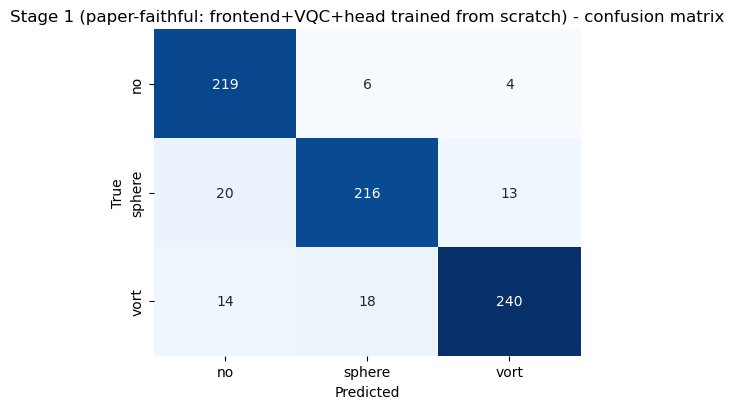

In [17]:
# CELL 7 — Shared eval helpers + Stage 1 test-set evaluation

@torch.no_grad()
def collect_predictions(model: nn.Module, loader, dev):
    model.eval()
    all_logp, all_y = [], []
    for xb, yb in tqdm(loader, desc="eval", leave=False):
        xb = xb.to(dev, non_blocking=True)
        all_logp.append(model(xb).detach().cpu())
        all_y.append(yb.detach().cpu())
    logp  = torch.cat(all_logp, dim=0).numpy()
    y     = torch.cat(all_y,    dim=0).numpy()
    probs = np.exp(logp)
    return probs, probs.argmax(axis=1), y


def plot_confusion(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(5.0, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout(); plt.show()


def evaluate_classifier(model, loader, class_names, tag: str):
    probs, preds, y = collect_predictions(model, loader, device)
    acc = accuracy_score(y, preds)
    y_bin = label_binarize(y, classes=list(range(len(class_names))))
    macro_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    cm = confusion_matrix(y, preds)
    print(f"\n=== {tag} ===")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Macro ROC-AUC: {macro_auc:.4f}")
    print(classification_report(y, preds, target_names=class_names, digits=4))
    plot_confusion(cm, class_names, title=f"{tag} - confusion matrix")
    return {"tag": tag, "accuracy": acc, "macro_auc": macro_auc,
            "probs": probs, "preds": preds, "targets": y}


stage1_results = evaluate_classifier(
    stage1_model, test_loader, CLASS_NAMES,
    tag="Stage 1 (paper-faithful: frontend+VQC+head trained from scratch)")

In [18]:
# CELL 8 — Stage 2 model (vqc_finetune.py:VQC_FINETUNE analog)

class Stage2Model(nn.Module):
    """frontend (loaded) -> sigmoid*pi/2 -> VQC (fresh) -> Linear (fresh) -> log_softmax"""
    def __init__(self, frontend: nn.Module, n_qubits: int, n_qlayers: int, n_classes: int):
        super().__init__()
        self.frontend = frontend
        self.n_qubits = n_qubits
        self.vqc  = VQC(n_wires=n_qubits, n_qlayers=n_qlayers)
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        bsz = x.shape[0]
        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=x.device)
        pre_out = self.frontend(x)
        q_in = torch.sigmoid(pre_out) * (np.pi / 2.0)
        q_out = self.vqc(q_in, qdev)
        return F.log_softmax(self.head(q_out), dim=1)


def build_stage2_model(cfg) -> Stage2Model:
    fe = get_frontend(cfg["backbone"], cfg["n_qubits"], pretrained=cfg["pretrained"])
    return Stage2Model(fe, n_qubits=cfg["n_qubits"],
                       n_qlayers=cfg["n_qlayers"], n_classes=cfg["n_classes"])

In [19]:
# CELL 9 — Mirrors vqc_finetune.py:180-192: prefix-strip + key-by-key copy

def load_frontend_from_stage1(stage2_model: Stage2Model,
                              stage1_ckpt_path: str,
                              strict: bool = True) -> Stage2Model:
    saved = torch.load(stage1_ckpt_path, map_location="cpu", weights_only=True)
    fe_state = stage2_model.frontend.state_dict()
    fe_from_saved = {
        k[len("frontend."):]: v for k, v in saved.items() if k.startswith("frontend.")
    }
    n_loaded = 0
    for k in fe_state.keys():
        if k in fe_from_saved and fe_from_saved[k].shape == fe_state[k].shape:
            fe_state[k] = fe_from_saved[k]
            n_loaded += 1
    result = stage2_model.frontend.load_state_dict(fe_state, strict=strict)
    n_skipped = sum(1 for k in saved if not k.startswith("frontend."))
    print(f"[FE-load] frontend keys loaded: {n_loaded}/{len(fe_state)}")
    print(f"[FE-load] non-frontend keys (vqc.* / head.*) skipped: {n_skipped}")
    if getattr(result, "missing_keys", []):
        print(f"  missing:    {result.missing_keys}")
    if getattr(result, "unexpected_keys", []):
        print(f"  unexpected: {result.unexpected_keys}")
    return stage2_model

In [20]:
# CELL 10 — Stage 2 training: load frontend only, reset VQC + head, fine-tune

def get_stage2_param_groups(model: Stage2Model, cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    return [
        {"params": list(model.frontend.backbone.parameters()),
         "lr": cfg["lr_backbone"], "name": "backbone"},
        {"params": list(model.frontend.bridge.parameters()),
         "lr": cfg["lr_bridge"],   "name": "bridge"},
        {"params": list(model.vqc.parameters()) + list(model.head.parameters()),
         "lr": cfg["lr_quantum"],  "name": "quantum"},
    ]


def run_stage2(cfg, train_loader, val_loader, load_stage1: bool,
               ckpt_save_path: str, run_tag: str,
               augmenter: Optional[nn.Module] = None):
    torch.manual_seed(cfg["seed"])
    model = build_stage2_model(cfg).to(device)
    if load_stage1:
        model = load_frontend_from_stage1(model, cfg["stage1_ckpt"], strict=True)
    else:
        print(f"[{run_tag}] Skipping Stage-1 weights -> ImageNet-only.")

    cw = cfg.get("class_weights")
    if cw is not None and any(w != 1.0 for w in cw):
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.NLLLoss(weight=cw_t)
    else:
        criterion = nn.NLLLoss()

    optimizer = optim.Adam(get_stage2_param_groups(model, cfg), weight_decay=cfg["stage2_wd"])
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda e: warmup_cosine_factor(e, cfg["warmup_epochs"], cfg["stage2_epochs"]),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None
    print(f"[{run_tag}] augmentation: {'ON' if augmenter is not None else 'OFF'}")

    for epoch in range(cfg["stage2_epochs"]):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        pbar = tqdm(train_loader, desc=f"[{run_tag}] ep {epoch+1}/{cfg['stage2_epochs']}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if augmenter is not None and model.training:
                xb = augmenter(xb)
            optimizer.zero_grad(set_to_none=True)
            logp = model(xb)
            loss = criterion(logp, yb)
            loss.backward()
            if cfg.get("grad_clip"):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            tr_loss    += loss.item() * xb.size(0)
            tr_correct += (logp.argmax(1) == yb).sum().item()
            tr_total   += xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss, train_acc = tr_loss / tr_total, tr_correct / tr_total

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logp = model(xb)
                v_loss    += criterion(logp, yb).item() * xb.size(0)
                v_correct += (logp.argmax(1) == yb).sum().item()
                v_total   += xb.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_save_path)

        scheduler.step()
        lrs = " ".join(f"{g['name']}={g['lr']:.1e}" for g in optimizer.param_groups)
        print(f"[{run_tag}] ep {epoch+1:02d}/{cfg['stage2_epochs']} | {lrs} | "
              f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} {'*' if is_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n[{run_tag}] Best val acc: {best_val_acc:.4f}")
    print(f"[{run_tag}] Saved best ckpt: {ckpt_save_path}")
    return model, history


t0 = time.time()
pre_vqc_model, pre_vqc_history = run_stage2(
    CFG, train_loader, val_loader,
    load_stage1=True,
    ckpt_save_path=CFG["stage2_ckpt"],
    run_tag=f"Pre+{CFG['backbone']}-VQC",
    augmenter=augmenter,
)
print(f"[Pre+{CFG['backbone']}-VQC] total time: {(time.time()-t0)/60:.1f} min")

[FE-load] frontend keys loaded: 168/168
[FE-load] non-frontend keys (vqc.* / head.*) skipped: 28
[Pre+vit_small_patch16_224-VQC] augmentation: ON


[Pre+vit_small_patch16_224-VQC] ep 1/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+vit_small_patch16_224-VQC] ep 01/60 | backbone=1.2e-05 bridge=8.0e-05 quantum=2.0e-03 | train loss=0.8936 acc=0.5263 | val loss=0.8262 acc=0.6012 *


[Pre+vit_small_patch16_224-VQC] ep 2/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+vit_small_patch16_224-VQC] ep 02/60 | backbone=1.8e-05 bridge=1.2e-04 quantum=3.0e-03 | train loss=0.7274 acc=0.6023 | val loss=0.6459 acc=0.5775 


...

[Pre+vit_small_patch16_224-VQC] ep 58/60 | backbone=9.8e-08 bridge=6.5e-07 quantum=1.6e-05 | train loss=0.1217 acc=0.9576 | val loss=0.2623 acc=0.9178 


[Pre+vit_small_patch16_224-VQC] ep 59/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+vit_small_patch16_224-VQC] ep 59/60 | backbone=2.4e-08 bridge=1.6e-07 quantum=4.1e-06 | train loss=0.1249 acc=0.9568 | val loss=0.2613 acc=0.9199 


[Pre+vit_small_patch16_224-VQC] ep 60/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+vit_small_patch16_224-VQC] ep 60/60 | backbone=0.0e+00 bridge=0.0e+00 quantum=0.0e+00 | train loss=0.1221 acc=0.9590 | val loss=0.2612 acc=0.9199 

[Pre+vit_small_patch16_224-VQC] Best val acc: 0.9227
[Pre+vit_small_patch16_224-VQC] Saved best ckpt: ./checkpoints/stage2/vit_small_patch16_224.pth
[Pre+vit_small_patch16_224-VQC] total time: 28.0 min


eval:   0%|          | 0/3 [00:00<?, ?it/s]


=== Pre+vit_small_patch16_224-VQC ===
Test accuracy: 0.9293
Macro ROC-AUC: 0.9806
Macro P/R/F1: 0.9290 / 0.9306 / 0.9289
              precision    recall  f1-score   support

          no     0.8960    0.9782    0.9353       229
      sphere     0.9362    0.8835    0.9091       249
        vort     0.9547    0.9301    0.9423       272

    accuracy                         0.9293       750
   macro avg     0.9290    0.9306    0.9289       750
weighted avg     0.9306    0.9293    0.9291       750



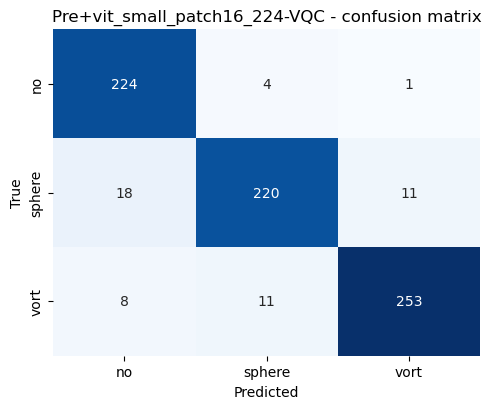

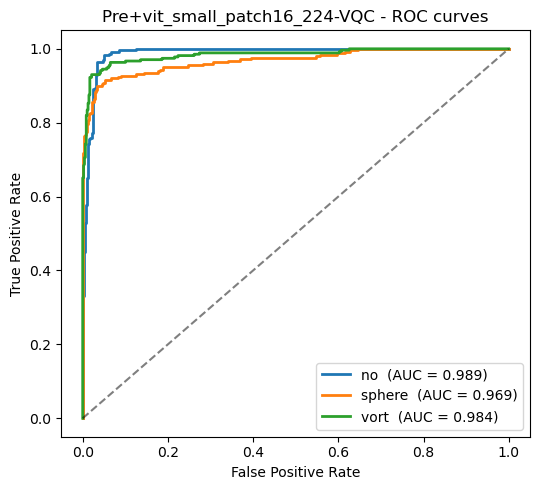

In [21]:
# CELL 11 — Stage 2 full evaluation: per-class P/R/F1, ROC curves, confusion matrix

def plot_roc_curves(probs, y, class_names, title):
    n_cls = len(class_names)
    y_bin = label_binarize(y, classes=list(range(n_cls)))
    fig, ax = plt.subplots(figsize=(5.5, 5.0))
    for i, cname in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        ax.plot(fpr, tpr, lw=2, label=f"{cname}  (AUC = {auc(fpr, tpr):.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(title); ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()


def evaluate_full(model, loader, class_names, tag: str):
    probs, preds, y = collect_predictions(model, loader, device)
    acc = accuracy_score(y, preds)
    y_bin = label_binarize(y, classes=list(range(len(class_names))))
    macro_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    p, r, f1, _ = precision_recall_fscore_support(y, preds, average=None, zero_division=0)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(y, preds, average="macro", zero_division=0)
    cm = confusion_matrix(y, preds)
    print(f"\n=== {tag} ===")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Macro ROC-AUC: {macro_auc:.4f}")
    print(f"Macro P/R/F1: {p_m:.4f} / {r_m:.4f} / {f1_m:.4f}")
    print(classification_report(y, preds, target_names=class_names, digits=4))
    plot_confusion(cm, class_names, title=f"{tag} - confusion matrix")
    plot_roc_curves(probs, y, class_names, title=f"{tag} - ROC curves")
    return {
        "tag": tag, "accuracy": acc, "macro_auc": macro_auc,
        "macro_precision": p_m, "macro_recall": r_m, "macro_f1": f1_m,
        "per_class_precision": dict(zip(class_names, p.tolist())),
        "per_class_recall":    dict(zip(class_names, r.tolist())),
        "per_class_f1":        dict(zip(class_names, f1.tolist())),
        "probs": probs, "preds": preds, "targets": y,
    }


pre_vqc_results = evaluate_full(
    pre_vqc_model, test_loader, CLASS_NAMES,
    tag=f"Pre+{CFG['backbone']}-VQC")

In [22]:
# # CELL 12 — Baseline: same Stage-2 schedule but front-end stays at ImageNet weights only

# t0 = time.time()
# baseline_model, baseline_history = run_stage2(
#     CFG, train_loader, val_loader,
#     load_stage1=False,
#     ckpt_save_path=CFG["baseline_ckpt"],
#     run_tag=f"ImageNet-only-{CFG['backbone']}-VQC",
#     augmenter=augmenter,
# )
# print(f"[ImageNet-only-{CFG['backbone']}-VQC] total time: {(time.time()-t0)/60:.1f} min")

# baseline_results = evaluate_full(
#     baseline_model, test_loader, CLASS_NAMES,
#     tag=f"ImageNet-only-{CFG['backbone']}-VQC")

In [23]:
# CELL 13 - Pure classical model: same frontend + bridge as Stage 1/2 but NO VQC

class ClassicalModel(nn.Module):
    """
    Pure-classical baseline:
        frontend (convnext_tiny + bridge MLP) -> Linear(n_qubits, n_classes) -> log_softmax

    Identical structure to Stage1Model except the sigmoid*pi/2 -> VQC block is dropped.
    The bridge output goes straight to the linear classifier.
    """
    def __init__(self, frontend: nn.Module, n_qubits: int, n_classes: int):
        super().__init__()
        self.frontend = frontend
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.frontend(x)
        return F.log_softmax(self.head(feats), dim=1)


def build_classical_model(cfg: Dict[str, Any]) -> ClassicalModel:
    fe = get_frontend(cfg["backbone"], cfg["n_qubits"], pretrained=cfg["pretrained"])
    return ClassicalModel(fe, n_qubits=cfg["n_qubits"], n_classes=cfg["n_classes"])


# Smoke test + parameter accounting
_m = build_classical_model(CFG).to(device)
_xb = torch.randn(2, 3, CFG["resize_to"], CFG["resize_to"], device=device)
_yb = _m(_xb)
print(f"ClassicalModel out shape: {tuple(_yb.shape)} (expected (2, {CFG['n_classes']}))")
print(f"ClassicalModel params: {sum(p.numel() for p in _m.parameters()):,}")
print(f"  backbone : {sum(p.numel() for p in _m.frontend.backbone.parameters()):,}")
print(f"  bridge   : {sum(p.numel() for p in _m.frontend.bridge.parameters()):,}")
print(f"  head     : {sum(p.numel() for p in _m.head.parameters()):,}")
print("  vqc      : 0  (pure classical baseline)")
del _m, _xb, _yb

ClassicalModel out shape: (2, 3) (expected (2, 3))
ClassicalModel params: 21,808,707
  backbone : 21,665,664
  bridge   : 143,016
  head     : 27
  vqc      : 0  (pure classical baseline)


In [ ]:
# CELL 14 - Train pure classical model (same backbone schedule, augmentation, weighted NLL)

CLASSICAL_DIR = os.path.join(CKPT_ROOT, "classical")
os.makedirs(CLASSICAL_DIR, exist_ok=True)
CFG["classical_ckpt"] = os.path.join(CLASSICAL_DIR, f"{_safe_name(CFG['backbone'])}.pth")


def get_classical_param_groups(model: ClassicalModel, cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    return [
        {"params": list(model.frontend.backbone.parameters()),
         "lr": cfg["stage1_lr_backbone"], "name": "backbone"},
        {"params": list(model.frontend.bridge.parameters()) + list(model.head.parameters()),
         "lr": cfg["stage1_lr_bridge"], "name": "bridge+head"},
    ]


def run_classical(cfg, train_loader, val_loader, augmenter: Optional[nn.Module] = None):
    torch.manual_seed(cfg["seed"])
    model = build_classical_model(cfg).to(device)

    cw = cfg.get("class_weights")
    if cw is not None and any(w != 1.0 for w in cw):
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.NLLLoss(weight=cw_t)
        print(f"[classical] using class weights {cw}")
    else:
        criterion = nn.NLLLoss()

    optimizer = optim.Adam(get_classical_param_groups(model, cfg), weight_decay=cfg["stage1_wd"])
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda e: warmup_cosine_factor(e, cfg["warmup_epochs"], cfg["stage1_epochs"]),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None
    print(f"[classical] pure classical: {cfg['backbone']} frontend + Linear({cfg['n_qubits']} -> {cfg['n_classes']}) (NO VQC)")
    print(f"[classical] augmentation: {'ON' if augmenter is not None else 'OFF'}")
    print(f"[classical] trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    for epoch in range(cfg["stage1_epochs"]):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        pbar = tqdm(train_loader, desc=f"[classical] ep {epoch+1}/{cfg['stage1_epochs']}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if augmenter is not None and model.training:
                xb = augmenter(xb)
            optimizer.zero_grad(set_to_none=True)
            logp = model(xb)
            loss = criterion(logp, yb)
            loss.backward()
            if cfg.get("grad_clip"):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            tr_loss += loss.item() * xb.size(0)
            tr_correct += (logp.argmax(1) == yb).sum().item()
            tr_total += xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss, train_acc = tr_loss / tr_total, tr_correct / tr_total

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logp = model(xb)
                v_loss += criterion(logp, yb).item() * xb.size(0)
                v_correct += (logp.argmax(1) == yb).sum().item()
                v_total += xb.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, cfg["classical_ckpt"])

        scheduler.step()
        lrs = " ".join(f"{g['name']}={g['lr']:.1e}" for g in optimizer.param_groups)
        print(f"[classical] ep {epoch+1:02d}/{cfg['stage1_epochs']} | {lrs} | "
              f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} {'*' if is_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n[classical] Best val acc: {best_val_acc:.4f}")
    print(f"[classical] Saved best ckpt: {cfg['classical_ckpt']}")
    return model, history


t0 = time.time()
classical_model, classical_history = run_classical(
    CFG, train_loader, val_loader, augmenter=augmenter,
)
print(f"[classical] total time: {(time.time()-t0)/60:.1f} min")

[classical] using class weights [1.0, 2.5, 2.0]
[classical] pure classical: vit_small_patch16_224 frontend + Linear(8 -> 3) (NO VQC)
[classical] augmentation: ON
[classical] trainable params: 21,808,707


[classical] ep 1/50:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 01/50 | backbone=2.0e-05 bridge+head=2.0e-04 | train loss=1.0557 acc=0.3335 | val loss=1.0359 acc=0.3335 *


[classical] ep 2/50:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 02/50 | backbone=3.0e-05 bridge+head=3.0e-04 | train loss=1.0119 acc=0.3655 | val loss=0.9375 acc=0.4702 *


...

[classical] ep 47/50:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 47/50 | backbone=5.5e-07 bridge+head=5.5e-06 | train loss=0.1643 acc=0.9417 | val loss=0.2528 acc=0.9135 


[classical] ep 48/50:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 48/50 | backbone=2.4e-07 bridge+head=2.4e-06 | train loss=0.1606 acc=0.9437 | val loss=0.2550 acc=0.9154 


[classical] ep 49/50:   0%|          | 0/118 [00:00<?, ?it/s]

In [ ]:
# CELL 15 - Evaluate pure classical model

classical_results = evaluate_full(
    classical_model, test_loader, CLASS_NAMES,
    tag=f"Classical-{CFG['backbone']} (no VQC)",
)

In [ ]:
# CELL 16 - Final comparison (robust: skips rows whose run has not been done yet)

TORCHQUANTUM_V10_REF = {
    "tag": "torchquantum_v10 (ResNet18+VQC, no Stage 1)",
    "accuracy": 0.9240,
    "macro_auc": 0.9837,
    "macro_precision": 0.9241,
    "macro_recall": 0.9243,
    "macro_f1": 0.9240,
}


def _row(d):
    return {
        "model": d["tag"],
        "test_accuracy": d.get("accuracy"),
        "macro_AUC": d.get("macro_auc"),
        "macro_precision": d.get("macro_precision"),
        "macro_recall": d.get("macro_recall"),
        "macro_F1": d.get("macro_f1"),
    }


rows = []
present = []
missing = []

for varname, label in [
    ("pre_vqc_results", "Pre+<Backbone>-VQC (Stage 1 -> Stage 2)"),
    ("baseline_results", "ImageNet-only-<Backbone>-VQC (no Stage 1)"),
    ("classical_results", "Pure classical <Backbone> (no VQC)"),
]:
    if varname in globals():
        rows.append(_row(globals()[varname]))
        present.append(label)
    else:
        missing.append((varname, label))

rows.append(_row(TORCHQUANTUM_V10_REF))
present.append("torchquantum_v10 (external reference)")

comparison_df = pd.DataFrame(rows)
for c in ["test_accuracy", "macro_AUC", "macro_precision", "macro_recall", "macro_F1"]:
    comparison_df[c] = pd.to_numeric(comparison_df[c], errors="coerce")

print("=== Runs included ===")
for p in present:
    print(f"  + {p}")
if missing:
    print("\n=== Runs missing (skipped) ===")
    for varname, label in missing:
        cell_hint = {
            "pre_vqc_results": "CELL 11",
            "baseline_results": "CELL 12",
            "classical_results": "CELL 14+15",
        }[varname]
        print(f"  - {label} (run {cell_hint} to add)")

print("\n=== Comparison ===")
print(comparison_df.to_string(index=False, na_rep="-", float_format="%.4f"))

if "pre_vqc_results" in globals() and "classical_results" in globals():
    classical_acc = classical_results["accuracy"]
    pre_vqc_acc = pre_vqc_results["accuracy"]
    classical_auc = classical_results["macro_auc"]
    pre_vqc_auc = pre_vqc_results["macro_auc"]

    print("\n=== Quantum-vs-classical analysis ===")
    print(f"Pure classical     | acc={classical_acc:.4f}  AUC={classical_auc:.4f}")
    if "baseline_results" in globals():
        b_acc = baseline_results["accuracy"]
        b_auc = baseline_results["macro_auc"]
        print(f"ImageNet-only-VQC  | acc={b_acc:.4f}  AUC={b_auc:.4f}  "
              f"(delta acc={b_acc - classical_acc:+.4f}, delta AUC={b_auc - classical_auc:+.4f})")
    print(f"Pre+{CFG['backbone']}-VQC | acc={pre_vqc_acc:.4f}  AUC={pre_vqc_auc:.4f}  "
          f"(delta acc={pre_vqc_acc - classical_acc:+.4f}, delta AUC={pre_vqc_auc - classical_auc:+.4f})")

    verdict = ("BEATS" if pre_vqc_acc > classical_acc
               else "LOSES TO" if pre_vqc_acc < classical_acc else "TIES")
    print(f"\nVerdict (Pre+VQC vs pure classical, on test acc): "
          f"quantum {verdict} classical by {abs(pre_vqc_acc - classical_acc)*100:.2f} %")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
mask_acc = comparison_df["test_accuracy"].notna()
mask_auc = comparison_df["macro_AUC"].notna()

if mask_acc.any():
    sub = comparison_df.loc[mask_acc]
    axes[0].bar(sub["model"], sub["test_accuracy"])
    axes[0].set_ylabel("Test accuracy")
    axes[0].set_ylim(max(0.0, sub["test_accuracy"].min() - 0.02), 1.0)
    axes[0].set_title("Test accuracy")
    axes[0].tick_params(axis="x", rotation=20)
    for i, v in enumerate(sub["test_accuracy"]):
        axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

if mask_auc.any():
    sub = comparison_df.loc[mask_auc]
    axes[1].bar(sub["model"], sub["macro_AUC"])
    axes[1].set_ylabel("Macro ROC-AUC")
    axes[1].set_ylim(max(0.0, sub["macro_AUC"].min() - 0.02), 1.0)
    axes[1].set_title("Macro ROC-AUC")
    axes[1].tick_params(axis="x", rotation=20)
    for i, v in enumerate(sub["macro_AUC"]):
        axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()